In [1]:
# Check pytorch version
import torch

print(torch.__version__)

2.5.1


In [2]:
!nvidia-smi

Tue Nov 26 02:54:48 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.59                 Driver Version: 556.13         CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 ...    On  |   00000000:01:00.0  On |                  N/A |
| N/A   64C    P0             20W /   80W |    1050MiB /   8188MiB |      5%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
print("Device Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU available")

Device Name: NVIDIA GeForce RTX 4060 Laptop GPU


In [4]:
# Use GPU for training
device = torch.device("cuda")

In [5]:
_exp_name = 'mnist'

In [6]:
# Import necessary packages
import torch.nn as nn
import torch.nn.functional as F 
import torch.optim
from torch.utils.data import DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
from omegaconf import OmegaConf
from tqdm.auto import tqdm

/home/patchouli/miniconda3/envs/cuda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# Fix random seed for reproducibility
seed = 114514
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Avoid nondeterministic algorithms and disable benchmarks for convolution operations
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [8]:
from torchvision import datasets, transforms

# Pipeline for preprocessing of the image. 
transform = transforms.Compose([

    # Resize into a fixed size
    transforms.Resize((128, 128)),

    # Transform to pytorch tensorc
    transforms.ToTensor(),

    # Normalizes the pixel values to have a mean value of 0 and a standard deviation of 1, assuming initially in range (0, 1)
    transforms.Normalize((0.5,), (0.5,))
])

# Download the MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)


Train dataset has 60000 samples.
Test dataset has 10000 samples.


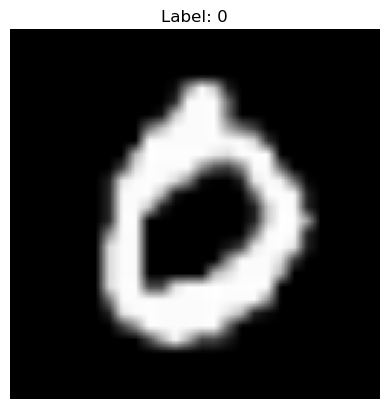

In [21]:
print(f'Train dataset has {len(train_dataset)} samples.')
print(f'Test dataset has {len(test_dataset)} samples.')

# Viualization of the first image
image_zero, target_zero = test_dataset[3]
plt.imshow(image_zero.squeeze().numpy(), cmap="gray")
plt.title(f"Label: {target_zero}")
plt.axis("off")
plt.show()

In [10]:
class Classfier(nn.Module):
    def __init__(self):
        # inherit attributes and methods of nn.Module
        super(Classfier, self).__init__()

        self.cnn = nn.Sequential(
            # Input size is [128, 128, 1]
            self.cnn_layer(in_channels=1, out_channels=64),     # [64, 64, 64]

            self.cnn_layer(in_channels=64, out_channels=128),       # [32, 32, 128]

            self.cnn_layer(in_channels=128, out_channels=256),      # [16, 16, 256]

            self.cnn_layer(in_channels=256, out_channels=512),       # [8, 8, 512]

            self.cnn_layer(in_channels=512, out_channels=512)       # [4, 4, 512]
        )

        self.fc = nn.Sequential(
            nn.Linear(512*4*4, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
            # nn.Softmax(dim=1)
        )

    def cnn_layer(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, 
                  pooling_kernel_size=2, pooling_stride=2, pooling_padding=0):
        """
        Create a default CNN layer. In and out channels are required parameters
        Parameters:
        - in_channels: Number of input channels.
        - out_channels: Number of output filter channels.
        - kernel_size: Size of the convolutional kernel.
        - stride: Stride of the convolution.
        - padding: Padding value added to the input.
        - pooling_kernel_size: Size of the maxpooling kernel.
        - pooling_stride: Stride of the maxpooling.
        - pooing_padding: Padding value added to the convolution output channel.

        Returns:
        - nn.Sequential: A block with convolution layer and pooling layer.
        """

        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
            # nn.BatchNorm2d(out_channels, eps=1e-05, momentum=0.1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.MaxPool2d(pooling_kernel_size, pooling_stride, pooling_padding)
        )
    
    def forward(self, x):

        filter = self.cnn(x)
        filter = filter.view(filter.size(0), -1)

        return self.fc(filter)

In [11]:
config = OmegaConf.load('config.yaml')
config_dict = OmegaConf.to_container(config, resolve=True)

In [22]:
# Divide MNIST dataset into training, vaildation and test sets

# 48,000 figures as training data, 12,000 figures as validation data
train_size = int(0.8 * len(train_dataset))
valid_size = len(train_dataset) - train_size
train, valid = random_split(train_dataset, [train_size, valid_size])

train_loader = DataLoader(train, batch_size=config_dict['batch_size'], shuffle=True)
valid_loader = DataLoader(valid, batch_size=config_dict['batch_size'], shuffle=True)

test_loader = DataLoader(test_dataset, batch_size=config_dict['batch_size'], shuffle=False, pin_memory=True)

In [13]:
# Initiallize the model to device
model = Classfier().to(device)

# Set up loss function and optimizer
criterion = getattr(nn, config_dict['criterion'])()

optimizer = torch.optim.Adam(model.parameters(), lr = config_dict['lr'], weight_decay=config_dict['weight_decay'])

patience = config_dict['patience']

In [14]:
"""
Start training
"""
n_epoches = config_dict['n_epoches']
stale = 0
best_acc = 0

for epoch in range(n_epoches):

    """ -----  Training  ----- """

    # Turn to train mode
    model.train()

    train_loss = []
    train_accs = []

    for batch in tqdm(train_loader):

        # Load data and label to device
        data, label = batch
        data, label = data.to(device), label.to(device)

        # Clear gradient buffers
        optimizer.zero_grad()

        # Forward propagation
        output = model(data)

        # Compute loss
        loss = criterion(output, label)

        # Backward propagation
        loss.backward()

        # Clip the gradient norms for stable training
        grad_norm = nn.utils.clip_grad_norm_(model.parameters(), max_norm=10)

        # Update the parameters
        optimizer.step()

        # Compute the accuracy for current batch
        acc = (output.argmax(dim=-1) == label).float().mean()

        # Record the loss and accuracy
        train_loss.append(loss.item())
        train_accs.append(acc)
    
    train_loss = sum(train_loss) / len(train_loss)
    train_acc = sum(train_accs) / len(train_accs)

    # Print the information.
    print(f"[ Train | {epoch + 1:03d}/{n_epoches:03d} ] loss = {train_loss:.5f}, acc = {train_acc:.5f}")


    """ -----  Validation  ----- """
    # Turn to validation mode
    model.eval()

    valid_loss = []
    valid_accs = []

    for batch in tqdm(valid_loader):

        data, label = batch
        data, label = data.to(device), label.to(device)

        # No need for gradient computation, so acclerate by no_grad
        with torch.no_grad():
            
            output = model(data)

        loss = criterion(output, label)
        acc = (output.argmax(dim=-1) == label.to(device)).float().mean()

        valid_loss.append(loss.item())
        valid_accs.append(acc)

    valid_loss = sum(valid_loss) / len(valid_loss)
    valid_acc = sum(valid_accs) / len(valid_accs)

    # Print the information.
    print(f"[ Valid | {epoch + 1:03d}/{n_epoches:03d} ] loss = {valid_loss:.5f}, acc = {valid_acc:.5f}")

    # update logs
    if valid_acc > best_acc:
        with open(f"./{_exp_name}_log.txt","a"):
            print(f"[ Valid | {epoch + 1:03d}/{n_epoches:03d} ] loss = {valid_loss:.5f}, acc = {valid_acc:.5f} -> best")
    else:
        with open(f"./{_exp_name}_log.txt","a"):
            print(f"[ Valid | {epoch + 1:03d}/{n_epoches:03d} ] loss = {valid_loss:.5f}, acc = {valid_acc:.5f}")


    # save models
    if valid_acc > best_acc:
        print(f"Best model found at epoch {epoch}, saving model")
        torch.save(model.state_dict(), f"{_exp_name}_best.ckpt") # only save best to prevent output memory exceed error
        best_acc = valid_acc
        stale = 0
    else:
        stale += 1
        if stale > patience:
            print(f"No improvment {patience} consecutive epochs, early stopping")
            break


100%|██████████| 750/750 [01:25<00:00,  8.77it/s]


[ Train | 001/005 ] loss = 0.84743, acc = 0.91565


100%|██████████| 188/188 [00:07<00:00, 24.81it/s]


[ Valid | 001/005 ] loss = 0.07243, acc = 0.98072
[ Valid | 001/005 ] loss = 0.07243, acc = 0.98072 -> best
Best model found at epoch 0, saving model


100%|██████████| 750/750 [01:24<00:00,  8.84it/s]


...

[ Valid | 004/005 ] loss = 0.07271, acc = 0.98063
[ Valid | 004/005 ] loss = 0.07271, acc = 0.98063


100%|██████████| 750/750 [01:25<00:00,  8.77it/s]


[ Train | 005/005 ] loss = 0.04087, acc = 0.98860


100%|██████████| 188/188 [00:07<00:00, 23.75it/s]


[ Valid | 005/005 ] loss = 0.03642, acc = 0.99003
[ Valid | 005/005 ] loss = 0.03642, acc = 0.99003 -> best
Best model found at epoch 4, saving model


In [23]:
model_best = Classfier().to(device)
model_best.load_state_dict(torch.load(f"{_exp_name}_best.ckpt"))
model_best.eval()
prediction = []
with torch.no_grad():
    for data,_ in tqdm(test_loader):
        test_pred = model_best(data.to(device))
        test_label = np.argmax(test_pred.cpu().data.numpy(), axis=1)
        prediction += test_label.squeeze().tolist()

/tmp/ipykernel_3044/1467414040.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_best.load_state_dict(torch.load(f"{_exp_name}_best.ckpt"))
100%|██████████| 157/157 

In [24]:
# create test csv
def pad4(i):
    return "0"*(4-len(str(i)))+str(i)
df = pd.DataFrame()
df["Id"] = [pad4(i) for i in range(len(test_dataset))]
df["Category"] = prediction
df.to_csv("submission.csv",index = False)